Project #1 — AI Text Classification System
We'll build a News/Article Topic Classifier.
You give it text such as:
“NVIDIA announced a new generation of GPUs designed for AI workloads…”

The model predicts:
Technology — 94% confidence

We'll classify text into categories such as Technology, Business, Sports, Politics and Entertainment.
What you'll learn
This connects directly to your early NLP/neural-network study:
Text → preprocessing → tokenization/vectorization → neural network → prediction
We'll gradually build:
Version 1
Dataset → clean text → TF-IDF → simple neural network → train/test → accuracy/confusion matrix.
Version 2
Replace TF-IDF with embeddings when you reach that part of your roadmap.
Version 3
Replace our basic model with a Transformer/BERT model when you've studied transformers.
So rather than making three unrelated tutorial projects, you'll see how the same NLP problem evolves from traditional NLP → neural networks → embeddings → transformers.

In [10]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")

print(dataset)

Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 2505046.00 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [18]:
print(dataset["train"][1])

{'text': 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.', 'label': 2}


here text = the news article/headline 
label =  its category
2 is what ??

In [12]:
print(dataset["train"].features["label"])
print(dataset["train"].features["label"])
print(dataset["train"].features["label"].names)

ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])
ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])
['World', 'Sports', 'Business', 'Sci/Tech']


In [13]:
import pandas as pd

df=dataset["train"].to_pandas()
df.head

<bound method NDFrame.head of                                                      text  label
0       Wall St. Bears Claw Back Into the Black (Reute...      2
1       Carlyle Looks Toward Commercial Aerospace (Reu...      2
2       Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3       Iraq Halts Oil Exports from Main Southern Pipe...      2
4       Oil prices soar to all-time record, posing new...      2
...                                                   ...    ...
119995  Pakistan's Musharraf Says Won't Quit as Army C...      0
119996  Renteria signing a top-shelf deal Red Sox gene...      1
119997  Saban not going to Dolphins yet The Miami Dolp...      1
119998  Today's NFL games PITTSBURGH at NY GIANTS Time...      1
119999  Nets get Carter from Raptors INDIANAPOLIS -- A...      1

[120000 rows x 2 columns]>

In [14]:
df.shape

(120000, 2)

In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    120000 non-null  str  
 1   label   120000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 28.9 MB


In [17]:
label_names = dataset["train"].features["label"].names 

for i, name in enumerate(label_names):
    print(i, "=" ,name )

0 = World
1 = Sports
2 = Business
3 = Sci/Tech


In [20]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df["category"] = df["label"].map(
 
    {
         0: "World",
         1: "Sports",
         2: "Business",
         3: "Sci/Tech"
    }
)

In [23]:
df.head()

,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [24]:
df.isnull().sum()

text        0
label       0
category    0
dtype: int64

In [25]:
df.head()

,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


TF = Term Frequency
Term Frequency asks:
How often does a word appear in this document?

Suppose an article says:
"AI technology uses AI models"

AI appears 2 times, while technology, uses, and models appear once.
So TF gives more importance to words that occur frequently within that particular document.
IDF = Inverse Document Frequency
Here's the problem: some words appear everywhere.
Imagine our news articles contain:
"the company announced the product"

In [26]:
df["category"].value_counts()

category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

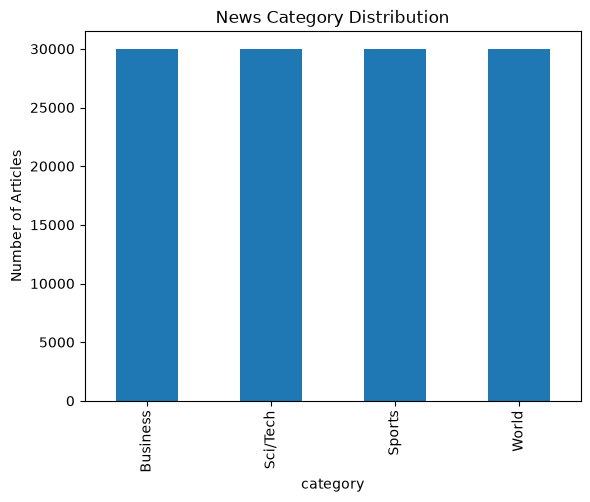

In [29]:
import matplotlib.pyplot as plt 

df["category"].value_counts().plot(kind="bar")

plt.title("News Category Distribution")
plt.xlabel("category")
plt.ylabel("Number of Articles")
plt.show()

In [30]:
x = df["text"]
y = df["label"]

In [31]:
x.head()

0    Wall St. Bears Claw Back Into the Black (Reute...
1    Carlyle Looks Toward Commercial Aerospace (Reu...
2    Oil and Economy Cloud Stocks' Outlook (Reuters...
3    Iraq Halts Oil Exports from Main Southern Pipe...
4    Oil prices soar to all-time record, posing new...
Name: text, dtype: str

In [32]:
y.head()

0    2
1    2
2    2
3    2
4    2
Name: label, dtype: int64

In [33]:
print("X shape:" , x.shape)
print("y shape:" , y.shape)

X shape: (120000,)
y shape: (120000,)


training the validattion data 


In [43]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    x,
    y,
    test_size=0.2, 
    random_state = 42,
    stratify=y

)

understand ?
we are giving function x = 120000 articles 
and y 120000 labels 

the function keep[s each article corrected]

test size = 0.2

that means 20% into validattion test 

why call is x labels in stead of x_test??

AG News already gave us:
train → 120,000
test  →   7,600
Original training data
120,000
        ↓
   ┌───────────┐
   ↓           ↓
96,000       24,000
TRAIN       VALIDATION
   ↓           ↓
Learn       Tune/check


Original AG News test
7,600
   ↓
FINAL 
for random splir = 42  
makes the random split reproducible.
Run the notebook tomorrow → same split.
Someone clones your GitHub project → same split.
There's nothing special about 42; it's simply a commonly used fixed number.

for stratify = y 
keeps the same class proportion for both sets 


In [44]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (96000,)
X_val: (24000,)
y_train: (96000,)
y_val: (24000,)


In [45]:
print(y_train.value_counts(normalize=True))

label
1    0.25
3    0.25
0    0.25
2    0.25
Name: proportion, dtype: float64


turnNING LANGUAGE INTO NUMBER 


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

Why this line?
sklearn is scikit-learn.
feature_extraction contains tools that turn raw data into features a machine-learning model can use.
.text means we're specifically working with text.
TfidfVectorizer is the class that will: English text
    ↓
TF-IDF
    ↓
Numerical features

In [47]:
tfidf = TfidfVectorizer(
    max_features=20000,
    stop_words="english"
)

In [48]:
X_train_tfidf = tfidf.fit_transform(X_train)

fit

TF-IDF examines only our training articles and learns things such as:

Which words exist?
How frequently do they occur?
How important are they?
What should our vocabulary contain?

For example, it might learn:

"football"
"microsoft"
"stocks"
"government"
"software"

transform

It then converts every training article into numbers using that learned vocabulary.


Learn the TF-IDF vocabulary from the training data AND convert the training articles into TF-IDF vectors.

In [50]:
#transform validattion data
X_val_tfidf = tfidf.transform(X_val)


In [51]:
print(X_train_tfidf.shape)
print(X_val_tfidf.shape)

(96000, 20000)
(24000, 20000)


In [52]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:20])

['00' '000' '000m' '000th' '005930' '01' '02' '03' '04' '05' '06' '07'
 '070' '08' '09' '10' '100' '1000' '100gb' '100m']


In [53]:
print(feature_names[1000:1020])

['alcan' 'alcatel' 'alcoa' 'alcohol' 'alcs' 'alderson' 'alejandro' 'alert'
 'alerts' 'alessandro' 'alex' 'alexander' 'alexandria' 'alexei' 'alfonso'
 'alfred' 'algae' 'algeria' 'algerian' 'algorithms']


In [54]:
article_index = 0

print("Article:")
print(X_train.iloc[article_index])

print("\nActual category:")
print(label_names[y_train.iloc[article_index]])

Article:
Clijsters Unsure About Latest Injury, Says Hewitt  TOKYO (Reuters) - Belgian Kim Clijsters is unsure about the  exact nature of the injury that has prematurely ended her  season, her fiance Lleyton Hewitt said on Wednesday.

Actual category:
Sports


In [55]:
article_vector = X_train_tfidf[article_index]

In [57]:
non_zero_indices = article_vector.nonzero()[1]

In [58]:
word_scores = []

for index in non_zero_indices:
    word = feature_names[index]
    score = article_vector[0, index]
    word_scores.append((word, score))

In [59]:
word_scores = sorted(
    word_scores,
    key=lambda x: x[1],
    reverse=True
)

print(word_scores[:10])

[('unsure', np.float64(0.47207721139223313)), ('clijsters', np.float64(0.43526314497581403)), ('hewitt', np.float64(0.3641285159169873)), ('injury', np.float64(0.3054265518590658)), ('fiance', np.float64(0.25051826325316456)), ('exact', np.float64(0.22428996004467006)), ('belgian', np.float64(0.1975113107177843)), ('nature', np.float64(0.19611917731077455)), ('kim', np.float64(0.19035298421692365)), ('lleyton', np.float64(0.18733277340643936))]


In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
#create model
model = LogisticRegression(
    max_iter=1000
)

In [64]:
model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [66]:
y_pred = model.predict(X_val_tfidf)

In [67]:
print("Predicted:", y_pred[:10])
print("Actual:   ", y_val.iloc[:10].values)

Predicted: [2 1 1 3 0 3 2 3 2 1]
Actual:    [2 1 2 2 0 3 2 3 2 1]


In [68]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_pred)

print(f"Validation Accuracy: {accuracy:.2%}")

Validation Accuracy: 91.90%


In [69]:
from sklearn.metrics import confusion_matrix

In [70]:
cm = confusion_matrix(y_val, y_pred)

print(cm)

[[5437  180  242  141]
 [  66 5883   27   24]
 [ 186   41 5341  432]
 [ 171   69  365 5395]]


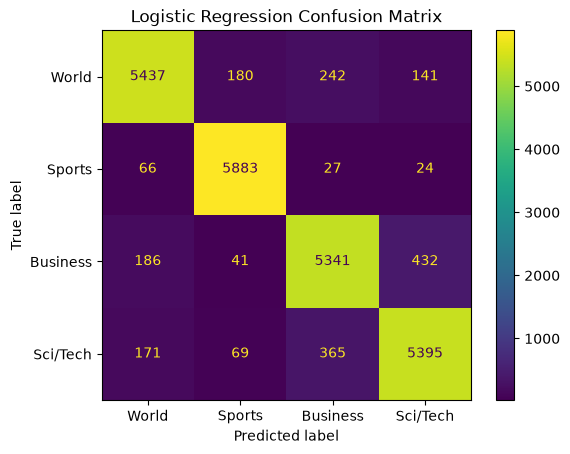

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names
)

display.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [72]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

print(cm)

[[5437  180  242  141]
 [  66 5883   27   24]
 [ 186   41 5341  432]
 [ 171   69  365 5395]]


In [73]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_pred,
        target_names=label_names
    )
)

              precision    recall  f1-score   support

       World       0.93      0.91      0.92      6000
      Sports       0.95      0.98      0.97      6000
    Business       0.89      0.89      0.89      6000
    Sci/Tech       0.90      0.90      0.90      6000

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000



## Model Evaluation — Logistic Regression

The Logistic Regression model was evaluated on the validation dataset containing **24,000 news articles**.

### Overall Performance

- **Validation Accuracy:** 91.90%
- **Macro F1-Score:** 0.92
- **Weighted F1-Score:** 0.92

### Classification Report

| Category | Precision | Recall | F1-Score | Support |
|---|---:|---:|---:|---:|
| World | 0.93 | 0.91 | 0.92 | 6,000 |
| Sports | 0.95 | 0.98 | 0.97 | 6,000 |
| Business | 0.89 | 0.89 | 0.89 | 6,000 |
| Sci/Tech | 0.90 | 0.90 | 0.90 | 6,000 |

### Interpretation

**Sports** was the best-performing category with an F1-score of **0.97** and recall of **0.98**. This suggests that sports-related vocabulary is highly distinctive and easier for the TF-IDF + Logistic Regression model to identify.

**Business** was the most challenging category, with an F1-score of **0.89**. The confusion matrix showed that Business articles were sometimes incorrectly classified as Sci/Tech.

A similar pattern occurred in the opposite direction, where some Sci/Tech articles were classified as Business. This is reasonable because technology-related news often contains business-related vocabulary such as company names, products, markets, revenue, and investments.

### Confusion Matrix Findings

The model correctly classified:

- **World:** 5,437 / 6,000
- **Sports:** 5,883 / 6,000
- **Business:** 5,341 / 6,000
- **Sci/Tech:** 5,395 / 6,000

The most noticeable confusion occurred between:

**Business ↔ Sci/Tech**

### Conclusion

The TF-IDF + Logistic Regression model provides a strong baseline for the news classification task, achieving approximately **92% validation accuracy**.

However, TF-IDF represents articles primarily through word importance rather than deeper semantic meaning or context. Future versions of the project can compare this baseline with more advanced text representations and models such as:

- Word embeddings
- Neural networks
- Transformer embeddings
- BERT

In [74]:
wrong_indices = y_val.values != y_pred

In [75]:
print("Misclassified articles:", wrong_indices.sum())

Misclassified articles: 1944


In [76]:
wrong_texts = X_val[wrong_indices]
wrong_actual = y_val[wrong_indices]
wrong_predicted = y_pred[wrong_indices]

In [77]:
i = 0

print("Article:")
print(wrong_texts.iloc[i])

print("\nActual:")
print(label_names[wrong_actual.iloc[i]])

print("\nPredicted:")
print(label_names[wrong_predicted[i]])

Article:
Olympians pursuit of marketing gold begins long before medals &lt;b&gt;...&lt;/b&gt; For millions of Americans, gymnast Paul Hamm #39;s fame began only when the broad-shouldered Olympian shrugged off a fall in the vaulting competition last week and made an inspired comeback to win gold.

Actual:
Business

Predicted:
Sports


### Error Analysis Example

One misclassified article had the following result:

**Actual Category:** Business  
**Predicted Category:** Sports

The article discussed Olympic gymnast Paul Hamm and contained sports-related terms such as *Olympian*, *gymnast*, *vaulting competition*, and *gold*. However, the main topic of the article was the marketing and commercial value associated with Olympic success.

The TF-IDF + Logistic Regression model likely focused strongly on the sports-related vocabulary and therefore classified the article as Sports.

This demonstrates an important limitation of TF-IDF-based text classification: TF-IDF captures the importance of words but has limited ability to understand the deeper context and overall meaning of an article.

More advanced contextual models, such as transformer-based models like BERT, may handle these ambiguous examples more effectively.

In [78]:
new_article = [
    "Apple announced a new artificial intelligence platform for its devices."
]

new_article_tfidf = tfidf.transform(new_article)

prediction = model.predict(new_article_tfidf)

predicted_category = label_names[prediction[0]]

print("Predicted category:", predicted_category)

Predicted category: Sci/Tech


In [79]:
probabilities = model.predict_proba(new_article_tfidf)

print(probabilities)

[[0.04778181 0.00644832 0.03768244 0.90808743]]


In [80]:
for category, probability in zip(label_names, probabilities[0]):
    print(f"{category}: {probability:.2%}")

World: 4.78%
Sports: 0.64%
Business: 3.77%
Sci/Tech: 90.81%


In [81]:
def predict_news(text):
    text_tfidf = tfidf.transform([text])

    prediction = model.predict(text_tfidf)[0]
    probabilities = model.predict_proba(text_tfidf)[0]

    predicted_category = label_names[prediction]

    print("Predicted Category:", predicted_category)
    print("\nProbabilities:")

    for category, probability in zip(label_names, probabilities):
        print(f"{category}: {probability:.2%}")

In [82]:
predict_news(
    "Manchester United won the championship after a dramatic final."
)

Predicted Category: Sports

Probabilities:
World: 0.18%
Sports: 99.71%
Business: 0.05%
Sci/Tech: 0.06%


In [83]:
predict_news(
    "Shares fell sharply after the company reported weaker quarterly profits."
)

Predicted Category: Business

Probabilities:
World: 0.26%
Sports: 0.05%
Business: 99.05%
Sci/Tech: 0.65%
